In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import skrf as rf
from IPython.display import Image, display
from scipy.optimize import curve_fit
prop_cycle = rcParams['axes.prop_cycle']   
colors = prop_cycle.by_key()['color']
import scipy.constants as sc
from skrf import Frequency, Network

In [2]:
path_fig="..//Figures/" 
path_Sonnet="..//Sonnet/"

Nous allons simuler le circuit de mesure d'un transmon couplé à une cavité (circuit ci-dessous). Les parties colorées du schéma sont simulées à l'aide du logiciel Sonner EM.

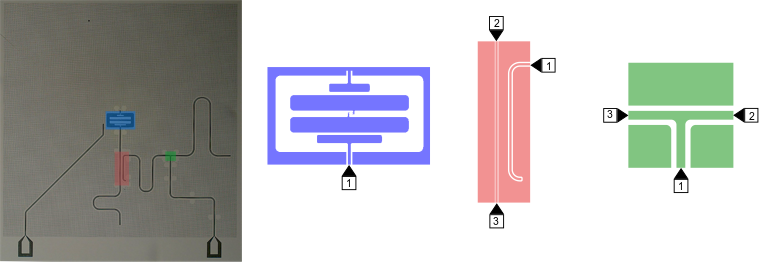

In [3]:
Image(filename=path_fig+"Simu_Board.png", width=800)

## Exercices

- Créer les éléments skrf correspondant aux fichier:
    - <span style="color: blue;">Qubit_junction_g.s1p </span>   (couplage capacitif du qubit dans l'état $|0 \rangle$)
    - <span style="color: blue;">Qubit_junction_e.s1p </span>   (couplage capacitif du qubit dans l'état $|1 \rangle$)
    - <span style="color: red;">Qubit_coupler.s3p </span>   (coupleur à 3 port)
    - <span style="color: green;">Qubit_T_connection.s3p </span>  (jonction en T à 3 port)
- Créer des lignes de transmission skrf d'impédance caractéristique $Z_0= 54.93 \Omega$ et de vitesse de propagation $v_g=1.26 \times 10^8 \, \mathrm{m.s}^{-1}$. On utilisera les longueur les lignes mesurer au niveau des plan de référence utilisés dans les simulation Sonnet ainsi que la plage de fréquence des fichier snp:
    - $L_{\mathrm{port-T}}=3939.5 \, \mu\mathrm{m}$
    - $L_{\mathrm{T-open}}= 5359.6 \, \mu\mathrm{m}$
    - $L_{\mathrm{coupler-T}}= 3398\, \mu\mathrm{m}$
    - $L_{\mathrm{coupler-capa}}=809.6 \, \mu\mathrm{m}$
    - $L_{\mathrm{coupler-short}}= 2888.6\, \mu\mathrm{m}$
- Créer 2 connexions simulant le qubit dans les états $|0 \rangle$ et $|1 \rangle$,
- [Interpoler les fréquences](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.networkSet.NetworkSet.interpolate_frequency.html) de l'ensemble de ces structures,
- Créer 2 [ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Port.html), un [ground](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Ground.html) et un [open](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Open.html), 
- Créer [connexions](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.connections_list.html) simulant le qubit dans les états $|0\rangle$ et  $|1\rangle$,
- Tracer la réponse en phase du résonanteur de lecture lorsque le qubit est respectivement dans l'état $|0 \rangle$ puis $|1 \rangle$,
- Déduire le shift dispersif $\chi$,
- Proposer une connexion permettant de voir l'effet du filtre Purcell.

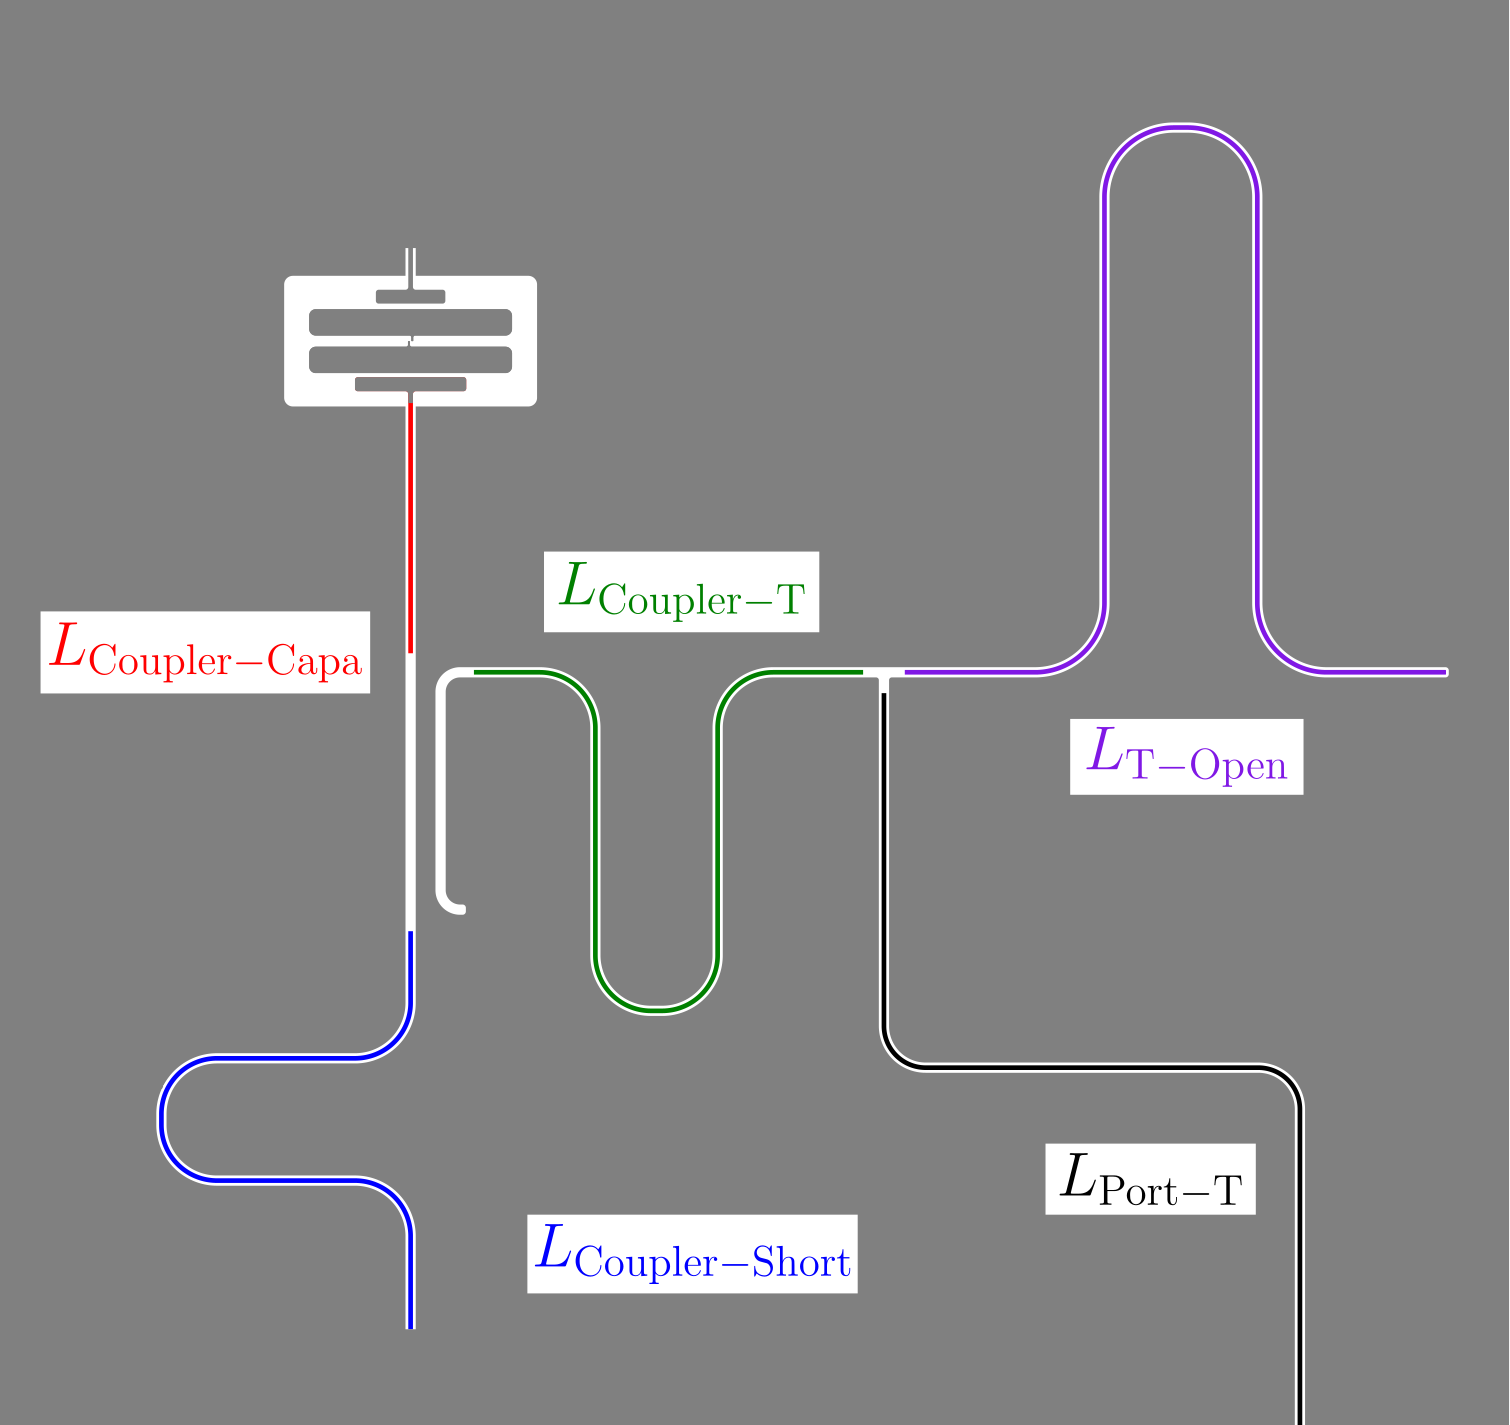

In [4]:
Image(filename=path_fig+"Longueur_transmon_lines.png", width=400)

# Coupler / T-Connection / Transmon 

In [5]:
coupler=rf.Network(path_Sonnet+"Qubit_coupler.s3p")
T_conn=rf.Network(path_Sonnet+"Qubit_T_connection.s3p")
Qubit_g=rf.Network(path_Sonnet+"Qubit_g.s1p")
Qubit_e=rf.Network(path_Sonnet+"Qubit_e.s1p")

L=[coupler.frequency,T_conn.frequency,Qubit_g.frequency,Qubit_e.frequency]
Len=[len(coupler.frequency.f),len(T_conn.frequency.f),len(Qubit_g.frequency.f),len(Qubit_e.frequency.f)]
M=max(Len)
ind=Len.index(M)

freq=L[ind]
f=freq.f
Nf=len(f)

In [6]:
print(Qubit_g.frequency)

3.0-7.0 GHz, 8001 pts


In [7]:
Zc=54.93
vg=1.26e8 

port_T = 3929.6e-6  # Length of CPW from T-connexion to measurement port (black line)


L_coupler_capa = 809.6e-6 # Length of the line between Qubit and coupler (red line)
L_coupler_short = 2809e-6 # Length of the line between coupler and shorted line (blue line)
L_T_open  =5389.6e-6 # Length of the right part of Purcell filter (purple line)
L_coupler_T = 3398e-6# Length of the CPW from T-connexion to coupler: left part of Purcell filter (green line)



# Ligne de transmission CPW
Le circuit (mis à part la jonction Josephson) est réalisé à l'aide d'un couche mince de tantal caractérisée par une température critique $T_c \simeq 4.4 \, \mathrm{K}$ et une inductance cinétique $L_k=0.2 \, \mathrm{pH/sq}$ déposé sur une substrat de saphir d'épaisseur $500 \, \mu \mathrm{m}$ (utiliser le general model pour créer un nouveau métal).

Simuler la ligne CPW ($w=17 \, \mu \mathrm{m} $, $g=10 \, \mu \mathrm{m}$ et en déduire son impédance caractéristique et la vitesse de propagation du signal. L'ensemble des simulation se feront entre 3 et 7 GHz.

CPW du port de mesure à la jonction en T

In [8]:
Nf=len(f)

s_port_T  = np.zeros((Nf, 2, 2), dtype=complex)
s_port_T [:, 0, 1] = np.exp(-1j * 2 * np.pi * f / vg * port_T )
s_port_T [:, 1, 0] = np.exp(-1j * 2 * np.pi * f / vg *port_T )
CPW_port_T = rf.Network(frequency=freq, s=s_port_T, z0=Zc ,name='CPW port_T')

CPW de la jonction en T à l'open de la lambda/2

In [9]:
s_T_open = np.zeros((Nf, 2, 2), dtype=complex)
s_T_open[:, 0, 1] = np.exp(-1j * 2 * np.pi * f / vg * L_T_open)
s_T_open[:, 1, 0] = np.exp(-1j * 2 * np.pi * f / vg * L_T_open)
CPW_T_open = rf.Network(frequency=freq, s=s_T_open, z0=Zc, name='CPW T_open')

CPW de la jonction en T au coupleuropen de la lambda/2

In [10]:
s_coupler_T = np.zeros((Nf, 2, 2), dtype=complex)
s_coupler_T[:, 0, 1] = np.exp(-1j * 2 * np.pi * f / vg * L_coupler_T)
s_coupler_T[:, 1, 0] = np.exp(-1j * 2 * np.pi * f / vg * L_coupler_T)
CPW_coupler_T = rf.Network(frequency=freq, s=s_coupler_T, z0=Zc, name='CPW coupler_T')

CPW du coupleur au couplage capacitif au Qubit

In [11]:
s_coupler_capa = np.zeros((Nf, 2, 2), dtype=complex)
s_coupler_capa[:, 0, 1] = np.exp(-1j * 2 * np.pi * f / vg * L_coupler_capa)
s_coupler_capa[:, 1, 0] = np.exp(-1j * 2 * np.pi * f / vg * L_coupler_capa)
CPW_coupler_capa = rf.Network(frequency=freq, s=s_coupler_capa, z0=Zc, name='CPW coupler_capa')

CPW du coupleur  à la terminaison short de la lambda/4

In [12]:
s_coupler_short = np.zeros((Nf, 2, 2), dtype=complex)
s_coupler_short[:, 0, 1] = np.exp(-1j * 2 * np.pi * f / vg *L_coupler_short)
s_coupler_short[:, 1, 0] = np.exp(-1j * 2 * np.pi * f / vg * L_coupler_short)
CPW_coupler_short = rf.Network(frequency=freq, s=s_coupler_short, z0=Zc, name='CPW_coupler_short')

# Simulation du réseau avec skrf

On considère la plage de fréquence la plus grande de toute les structure skrf

In [13]:
L=[coupler.frequency,T_conn.frequency,Qubit_g.frequency,Qubit_e.frequency]
Len=[len(coupler.frequency.f),len(T_conn.frequency.f),len(Qubit_g.frequency.f),len(Qubit_e.frequency.f)]
M=max(Len)
ind=Len.index(M)

freq=L[ind]
f=freq.f
Nf=len(f)

In [14]:
L

[3.0-7.0 GHz, 80001 pts,
 3.0-7.0 GHz, 80001 pts,
 3.0-7.0 GHz, 8001 pts,
 3.0-7.0 GHz, 8001 pts]

In [15]:
print(freq)

3.0-7.0 GHz, 80001 pts


In [16]:
coupler=coupler.interpolate(freq) 
T_conn=T_conn.interpolate(freq) 
Qubit_g=Qubit_g.interpolate(freq) 
Qubit_e=Qubit_e.interpolate(freq) 
CPW_port_T=CPW_port_T.interpolate(freq) 
CPW_T_open=CPW_T_open.interpolate(freq) 
CPW_coupler_T=CPW_coupler_T.interpolate(freq) 
CPW_coupler_capa=CPW_coupler_capa.interpolate(freq) 
CPW_coupler_short=CPW_coupler_short.interpolate(freq) 

In [17]:
print(T_conn)
print(coupler)
print(Qubit_g)
print(Qubit_e)
print(CPW_port_T)
print(CPW_coupler_T)
print(CPW_T_open)
print(CPW_coupler_capa)
print(CPW_coupler_short)

3-Port Network: 'Qubit_T_connection',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j 54.93+0.j 54.93+0.j]
3-Port Network: 'Qubit_coupler',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j 54.93+0.j 54.93+0.j]
1-Port Network: 'Qubit_g',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j]
1-Port Network: 'Qubit_e',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j]
2-Port Network: 'CPW port_T',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j 54.93+0.j]
2-Port Network: 'CPW coupler_T',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j 54.93+0.j]
2-Port Network: 'CPW T_open',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j 54.93+0.j]
2-Port Network: 'CPW coupler_capa',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j 54.93+0.j]
2-Port Network: 'CPW_coupler_short',  3.0-7.0 GHz, 80001 pts, z0=[54.93+0.j 54.93+0.j]


# Circuit

- créer 2 [ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Port.html), un [ground](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Ground.html) et un [open](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Open.html), 
- créer [connexions](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.connections_list.html) simulant le qubit dans les états $|0\rangle$ et  $|1\rangle$

In [18]:
port1 = rf.Circuit.Port(frequency=freq, name='port1', z0=50)
port2 = rf.Circuit.Port(frequency=freq, name='port2', z0=50)
ground0 = rf.Circuit.Ground(freq, name='GND0')
Open1 = rf.Circuit.Open(freq, name='Open', z0=Zc)



In [19]:
DUT=[]
DUT.append(Qubit_g) # ground state (Junction_param2.n1p)
DUT.append(Qubit_e) # excited state (Junction_param3.n1p)

In [20]:
connexion=[]
for k in range(2):
    connexion.append([[(port1, 0), (CPW_port_T, 0)],
                  [(CPW_port_T, 1), (T_conn,0)],
                  [(T_conn,1),(CPW_T_open,0)],
                  [(CPW_T_open, 1),(Open1,0)],
                  [(T_conn,2),(CPW_coupler_T,0)],
                  [(CPW_coupler_T,1),(coupler,0)],
                  [(coupler,1),(CPW_coupler_capa,0)],
                  [(CPW_coupler_capa,1),(DUT[k],0)],
                  [(coupler,2),(CPW_coupler_short,0)],
                  [(CPW_coupler_short,1),(ground0,0)]
                 ])
resulting_Circuit=[]

In [21]:
rf.Circuit(connexion[k])

<Figure size 640x480 with 0 Axes>

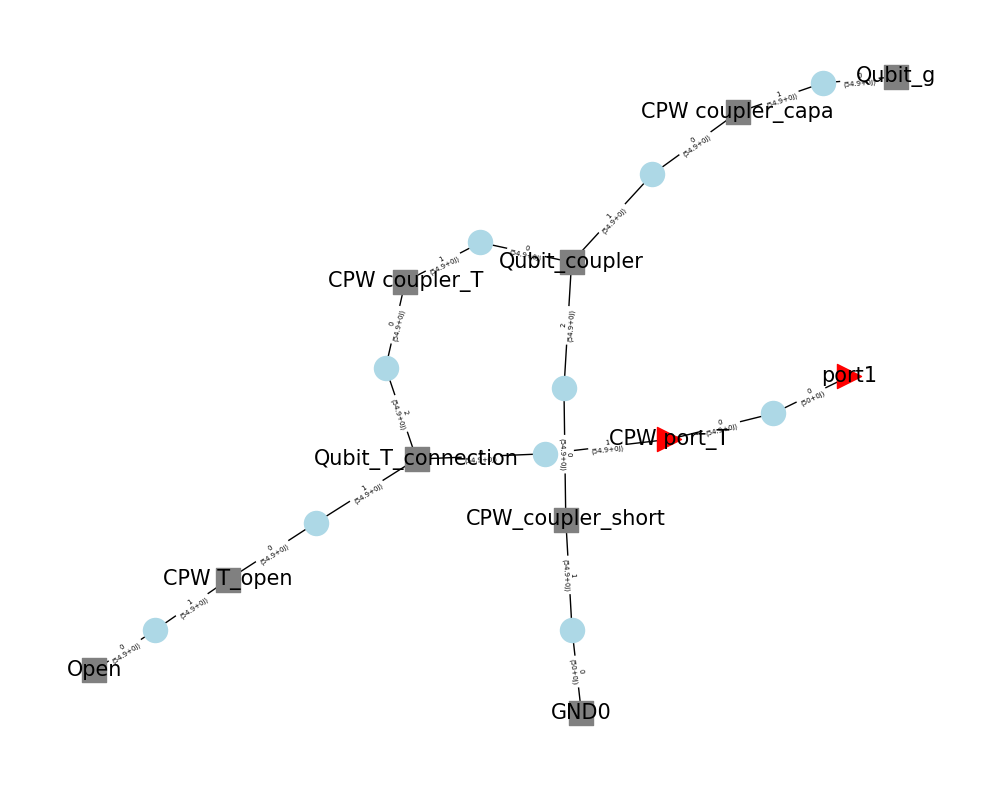

<Figure size 640x480 with 0 Axes>

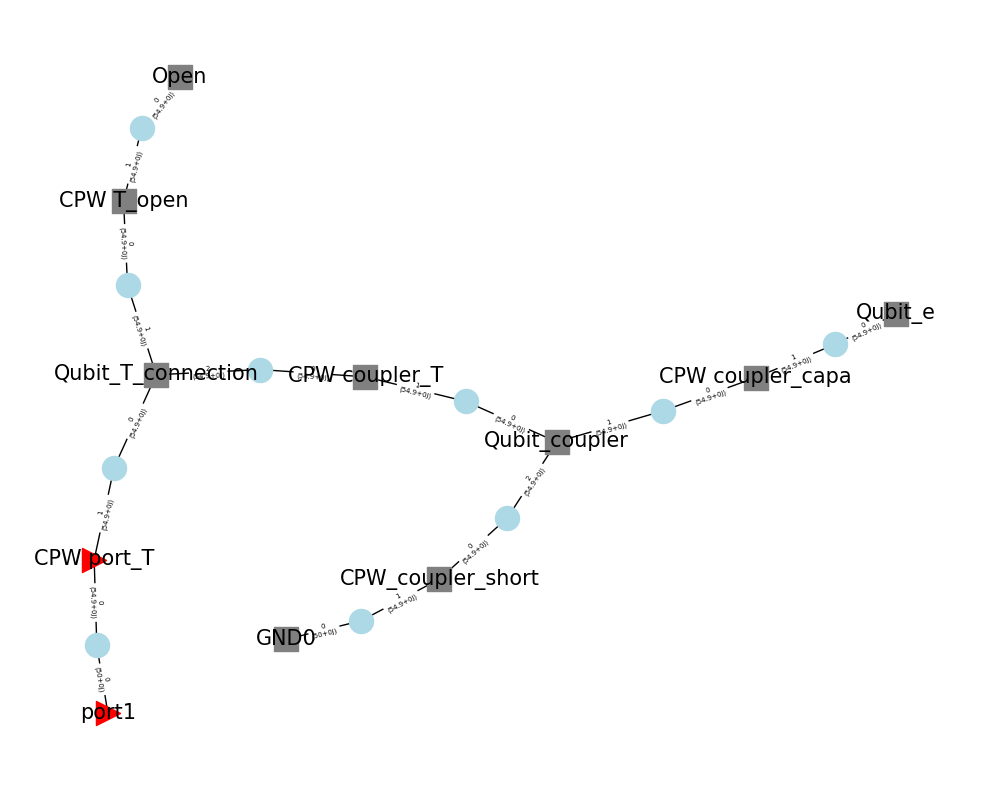

In [22]:
for k in range(2):
    resulting_Circuit.append(rf.Circuit(connexion[k]))
plt.figure()
resulting_Circuit[0].plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()
plt.figure()
resulting_Circuit[1].plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()

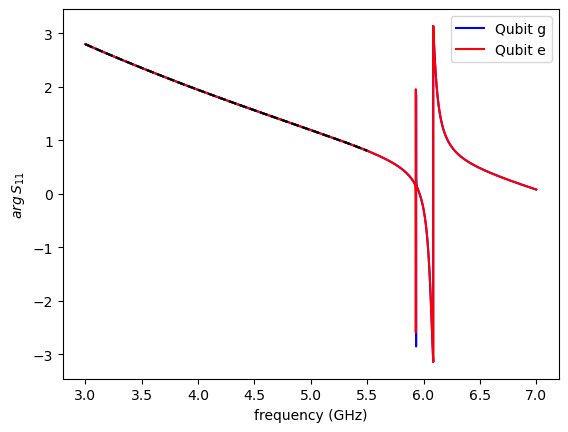

In [23]:
S11_raw=[]
S11_cal=[]
label_DUT= ['Qubit g','Qubit e']
plt.figure()
color_lines=['b','r']
for k in range(2):
    S11_raw.append(resulting_Circuit[k].s[:,0,0])
    plt.plot(1e-9*f,np.angle(S11_raw[k]), label=label_DUT[k],color=color_lines[k])
    plt.plot(1e-9*f[0:50000],np.angle(S11_raw[k][0:50000]),'--k', linewidth=1.5)
    plt.legend()
    plt.xlabel("frequency (GHz)")
    plt.ylabel("$arg\,  S_{11}$")
    p=np.polyfit(f[0:50000],np.unwrap(np.angle(resulting_Circuit[k].s[0:50000,0,0])),1) #propagation length
    S11_cal.append(S11_raw[k]*np.exp(-1j*p[0]*f))
plt.savefig(path_fig+'S11_dB_Transmon.svg')
plt.show()


On supprime la propagation en fittant les 30000 premiers points par une doite.

In [24]:
ind = np.where((f >5.92) & (f <5.938e9))
sig_g=np.unwrap(np.angle(S11_cal[0]))
sig_e=np.unwrap(np.angle(S11_cal[1]))
A=(sig_g[np.min(ind)]+sig_g[np.max(ind)])/2
ind_g = np.where(sig_g<A)
ind_e = np.where(sig_e<A)

Xe=(f[np.min(ind_g)])*1e-9
Xg=(f[np.min(ind_e)])*1e-9

print(Xe)
print(Xg)


5.93445
5.9316


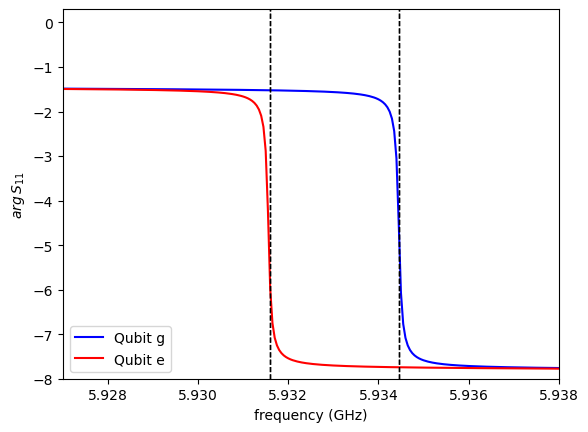

In [25]:
Ymin=-8
Ymax=0.3
plt.figure()
for k in [0,1]:
    plt.plot(1e-9*f,np.unwrap(np.angle(S11_cal[k])), label=label_DUT[k],color=color_lines[k])
    plt.legend(loc="lower left")
    plt.xlabel("frequency (GHz)")
    plt.ylabel("$arg\,  S_{11}$")
    plt.xlim(5.927,5.938)
    plt.ylim(Ymin,Ymax)
    plt.plot([Xe, Xe], [Ymin,Ymax], linestyle='--', color='black', linewidth=1)
    plt.plot([Xg, Xg], [Ymin,Ymax], linestyle='--', color='black', linewidth=1)
plt.savefig(path_fig+'S11_dB_Transmon_zoom.svg')
plt.show()

In [26]:
chi=(Xg-Xe)/2
print("chi = " + str(np.round(chi*1e3,2)) +" MHz")

chi = -1.42 MHz


In [27]:
np.sqrt(1.37e6*2.02e9)*1e-6

np.float64(52.60608329841711)

# Effet du filtre

- créer une connexion en remplaçant le qubit par un 2ème port,
- observer ce que "voit" le qubit en mesurant $S_{21}$ ([il faut intéroger le circuit pour savoir où sont connectés les ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.port_indexes.html) 1 et 2)

In [28]:
connexion_Purcell=[]

connexion_Purcell.append([[(port1, 0), (CPW_port_T, 0)],
                  [(CPW_port_T, 1), (T_conn,0)],
                  [(T_conn,1),(CPW_T_open,0)],
                  [(CPW_T_open, 1),(Open1,0)],
                  [(T_conn,2),(CPW_coupler_T,0)],
                  [(CPW_coupler_T,1),(coupler,0)],
                  [(coupler,1),(CPW_coupler_capa,0)],
                  [(CPW_coupler_capa,1),(port2,0)],
                  [(coupler,2),(CPW_coupler_short,0)],
                  [(CPW_coupler_short,1),(ground0,0)]
                 ])


resulting_CircuiT_open=[]

<Figure size 640x480 with 0 Axes>

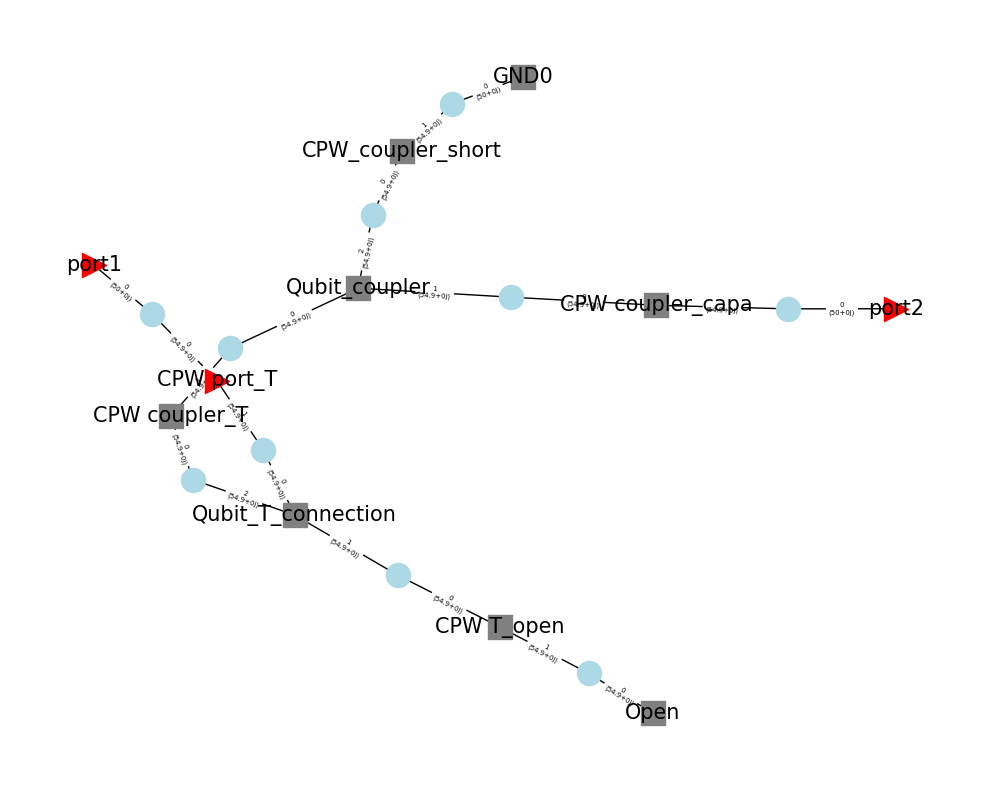

In [29]:
resulting_CircuiT_open.append(rf.Circuit(connexion_Purcell[0]))
resulting_CircuiT_open[0].port_indexes
plt.figure()
resulting_CircuiT_open[0].plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()

In [31]:
resulting_CircuiT_open[0].port_indexes

[0, 15]

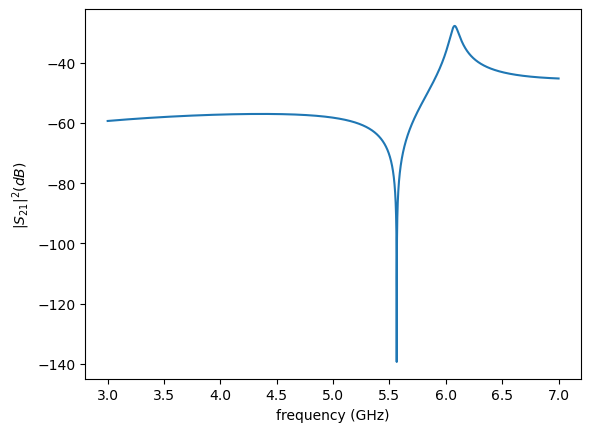

In [32]:
S21_Purcell=[]
S21_Purcell.append(resulting_CircuiT_open[0].s[:,15,0])
plt.figure()
plt.plot(1e-9*(resulting_CircuiT_open[0].frequency.f),20*np.log10(np.abs(S21_Purcell[0])))
plt.xlabel("frequency (GHz)")
plt.ylabel("$|S_{21}|^2 (dB)$")
plt.savefig(path_fig+'S21_Purcell.svg')
plt.show()

# Sans  du filtre

In [34]:
connexion_NoPurcell=[]

connexion_NoPurcell.append([[(port1, 0),(coupler,0)],
                  [(coupler,1),(CPW_coupler_capa,0)],
                  [(CPW_coupler_capa,1),(port2,0)],
                  [(coupler,2),(CPW_coupler_short,0)],
                  [(CPW_coupler_short,1),(ground0,0)]
                 ])


resulting_CircuiT_open=[]

<Figure size 640x480 with 0 Axes>

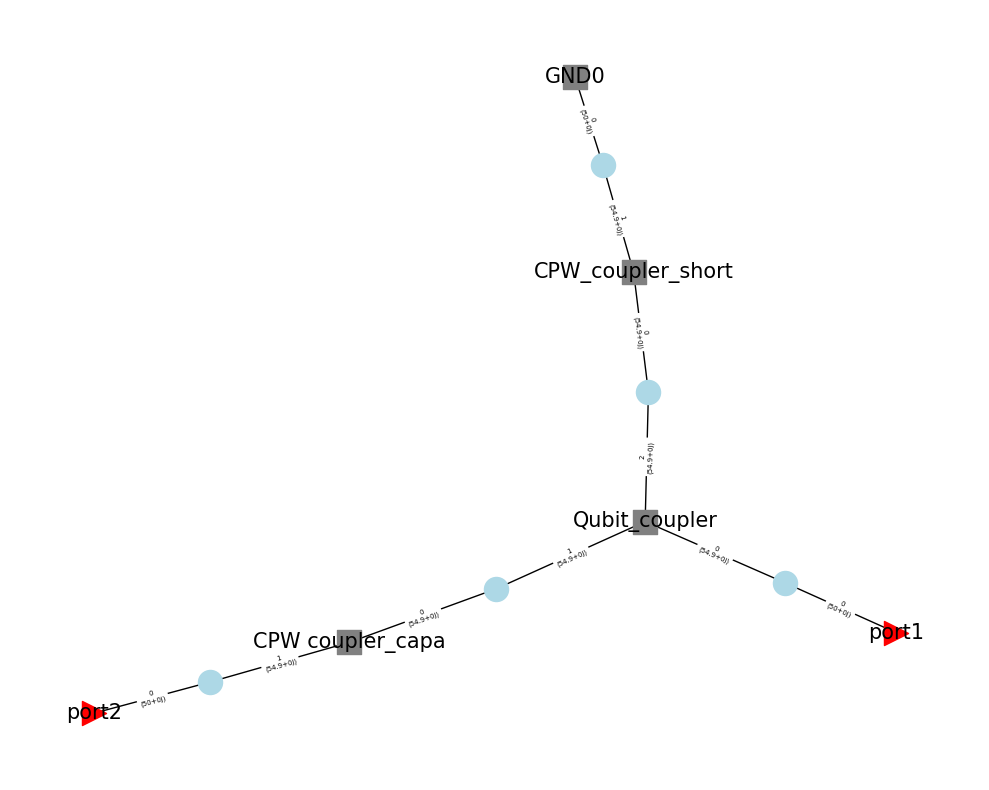

In [35]:
resulting_CircuiT_open.append(rf.Circuit(connexion_NoPurcell[0]))
resulting_CircuiT_open[0].port_indexes
plt.figure()
resulting_CircuiT_open[0].plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()

In [36]:
resulting_CircuiT_open[0].port_indexes

[0, 5]

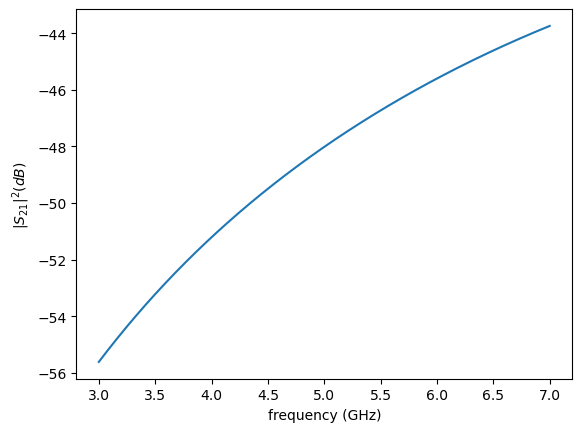

In [37]:
S21_Purcell=[]
S21_Purcell.append(resulting_CircuiT_open[0].s[:,5,0])
plt.figure()
plt.plot(1e-9*(resulting_CircuiT_open[0].frequency.f),20*np.log10(np.abs(S21_Purcell[0])))
plt.xlabel("frequency (GHz)")
plt.ylabel("$|S_{21}|^2 (dB)$")
plt.savefig(path_fig+'S21_Purcell.svg')
plt.show()